# xDAWN + LDA — Extended Evaluation
Method B: 8-train / 1-valid / 1-test (10 folds)
Method C: Pooled 70/10/20 per subject (5 reps)

In [1]:
import numpy as np, os, time, copy, warnings, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.calibration import calibration_curve
from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace
warnings.filterwarnings('ignore')

import importlib.util
spec = importlib.util.spec_from_file_location("cfg", "00_config.py")
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)
for a in dir(cfg):
    if not a.startswith('_'): globals()[a] = getattr(cfg, a)

data = np.load(CKPT['clf_data'])
X = data['X_epochs']; y = data['y']; groups = data['groups']
subjects = np.load(CKPT['subjects'], allow_pickle=True).tolist()
n_subs = len(subjects)

def make_pipe():
    return Pipeline([
        ('xdawn_cov', XdawnCovariances(nfilter=4, estimator='lwf')),
        ('ts', TangentSpace(metric='riemann')),
        ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    ])

print(f"X={X.shape} tgt={sum(y==1)} ntgt={sum(y==0)}")

X=(3600, 32, 701) tgt=600 ntgt=3000


## Method B — 8 Train / 1 Valid / 1 Test

In [2]:
t0 = time.time()
b_tr, b_va, b_te = [], [], []
b_yt, b_yp = [], []

for test_sub in range(n_subs):
    valid_sub = (test_sub + 1) % n_subs
    te_mask = groups == test_sub
    va_mask = groups == valid_sub
    tr_mask = ~te_mask & ~va_mask

    pipe = make_pipe()
    pipe.fit(X[tr_mask], y[tr_mask])

    ba_tr = balanced_accuracy_score(y[tr_mask], pipe.predict(X[tr_mask]))
    ba_va = balanced_accuracy_score(y[va_mask], pipe.predict(X[va_mask]))
    yp = pipe.predict(X[te_mask])
    ba_te = balanced_accuracy_score(y[te_mask], yp)

    b_tr.append(ba_tr); b_va.append(ba_va); b_te.append(ba_te)
    b_yt.extend(y[te_mask]); b_yp.extend(yp)

    gap = ba_tr - ba_te
    flag = " ⚠" if gap > 0.15 else ""
    print(f"  test={subjects[test_sub]:<7} valid={subjects[valid_sub]:<7} "
          f"tr={ba_tr:.3f} va={ba_va:.3f} te={ba_te:.3f} gap={gap:+.3f}{flag}")

b_tr,b_va,b_te = np.array(b_tr),np.array(b_va),np.array(b_te)
print(f"\nB: test={np.mean(b_te):.3f}±{np.std(b_te):.3f} gap={np.mean(b_tr-b_te):+.3f} ({time.time()-t0:.0f}s)")

  test=sub-010 valid=sub-011 tr=0.921 va=0.675 te=0.892 gap=+0.030
  test=sub-011 valid=sub-012 tr=0.910 va=0.817 te=0.712 gap=+0.198 ⚠
  test=sub-012 valid=sub-013 tr=0.903 va=0.872 te=0.798 gap=+0.105
  test=sub-013 valid=sub-014 tr=0.912 va=0.917 te=0.830 gap=+0.082
  test=sub-014 valid=sub-015 tr=0.899 va=0.982 te=0.867 gap=+0.032
  test=sub-015 valid=sub-016 tr=0.905 va=0.948 te=0.980 gap=-0.075
  test=sub-016 valid=sub-019 tr=0.895 va=0.658 te=0.912 gap=-0.016
  test=sub-019 valid=sub-020 tr=0.934 va=0.557 te=0.647 gap=+0.287 ⚠
  test=sub-020 valid=sub-021 tr=0.913 va=0.838 te=0.637 gap=+0.276 ⚠
  test=sub-021 valid=sub-010 tr=0.907 va=0.892 te=0.855 gap=+0.052

B: test=0.813±0.109 gap=+0.097 (159s)


## Method C — Pooled 70/10/20

In [3]:
t0 = time.time()
c_tr, c_va, c_te = [], [], []
c_per_sub = {s:[] for s in subjects}

for rep in range(5):
    tr_idx, va_idx, te_idx = [], [], []
    for si in range(n_subs):
        mask = np.where(groups == si)[0]
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42+rep)
        tv, te = next(sss1.split(mask, y[mask]))
        tv_idx = mask[tv]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.125, random_state=142+rep)
        tr, va = next(sss2.split(tv_idx, y[tv_idx]))
        tr_idx.extend(tv_idx[tr]); va_idx.extend(tv_idx[va]); te_idx.extend(mask[te])

    tr_idx,va_idx,te_idx = np.array(tr_idx),np.array(va_idx),np.array(te_idx)
    pipe = make_pipe()
    pipe.fit(X[tr_idx], y[tr_idx])

    ba_tr = balanced_accuracy_score(y[tr_idx], pipe.predict(X[tr_idx]))
    ba_va = balanced_accuracy_score(y[va_idx], pipe.predict(X[va_idx]))
    ba_te = balanced_accuracy_score(y[te_idx], pipe.predict(X[te_idx]))
    c_tr.append(ba_tr); c_va.append(ba_va); c_te.append(ba_te)

    for si,s in enumerate(subjects):
        st = [i for i in te_idx if groups[i]==si]
        if st: c_per_sub[s].append(balanced_accuracy_score(y[st], pipe.predict(X[st])))

    print(f"  rep {rep+1}: tr={ba_tr:.3f} va={ba_va:.3f} te={ba_te:.3f} gap={ba_tr-ba_te:+.3f}")

c_tr,c_va,c_te = np.array(c_tr),np.array(c_va),np.array(c_te)
print(f"\nC: test={np.mean(c_te):.3f}±{np.std(c_te):.3f} gap={np.mean(c_tr-c_te):+.3f} ({time.time()-t0:.0f}s)")

  rep 1: tr=0.899 va=0.923 te=0.900 gap=-0.001
  rep 2: tr=0.909 va=0.853 te=0.900 gap=+0.009
  rep 3: tr=0.894 va=0.888 te=0.877 gap=+0.016
  rep 4: tr=0.900 va=0.900 te=0.878 gap=+0.022
  rep 5: tr=0.890 va=0.893 te=0.887 gap=+0.003

C: test=0.889±0.010 gap=+0.010 (84s)


## Overfitting Check

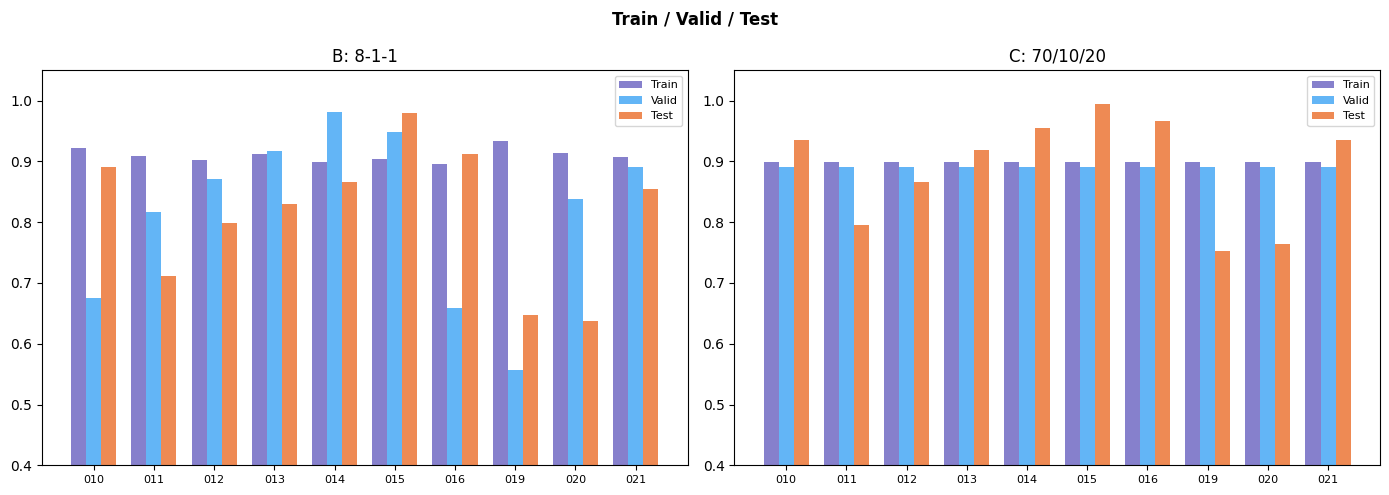


Method        Train  Valid   Test    Gap
----------------------------------------
B: 8-1-1      0.910  0.816  0.813 +0.097
C: 70/10/20   0.898  0.892  0.889 +0.010

C vs B: +0.076 (within-subject helps)


In [4]:
# train vs test bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(n_subs); w = 0.25

ax = axes[0]
ax.bar(x-w, b_tr, w, label='Train', color='#534AB7', alpha=.7)
ax.bar(x, b_va, w, label='Valid', color='#2196F3', alpha=.7)
ax.bar(x+w, b_te, w, label='Test', color='#E8590C', alpha=.7)
ax.set_xticks(x); ax.set_xticklabels([s[-3:] for s in subjects], fontsize=8)
ax.set_title('B: 8-1-1'); ax.set_ylim(0.4,1.05); ax.legend(fontsize=8)

ax = axes[1]
c_sub_te = [np.mean(c_per_sub[s]) for s in subjects]
ax.bar(x-w, [np.mean(c_tr)]*n_subs, w, label='Train', color='#534AB7', alpha=.7)
ax.bar(x, [np.mean(c_va)]*n_subs, w, label='Valid', color='#2196F3', alpha=.7)
ax.bar(x+w, c_sub_te, w, label='Test', color='#E8590C', alpha=.7)
ax.set_xticks(x); ax.set_xticklabels([s[-3:] for s in subjects], fontsize=8)
ax.set_title('C: 70/10/20'); ax.set_ylim(0.4,1.05); ax.legend(fontsize=8)

plt.suptitle('Train / Valid / Test', fontweight='bold')
plt.tight_layout(); plt.show()

# summary
print(f"\n{'Method':<12} {'Train':>6} {'Valid':>6} {'Test':>6} {'Gap':>6}")
print("-"*40)
print(f"{'B: 8-1-1':<12} {np.mean(b_tr):>6.3f} {np.mean(b_va):>6.3f} {np.mean(b_te):>6.3f} {np.mean(b_tr-b_te):>+6.3f}")
print(f"{'C: 70/10/20':<12} {np.mean(c_tr):>6.3f} {np.mean(c_va):>6.3f} {np.mean(c_te):>6.3f} {np.mean(c_tr-c_te):>+6.3f}")
diff = np.mean(c_te) - np.mean(b_te)
print(f"\nC vs B: {diff:+.3f} ({'within-subject helps' if diff>0.03 else 'similar'})")

In [5]:
# save
np.savez(result_path('xdawn_lda'),
    method='xdawn_lda',
    per_subject_scores=b_te, y_true=np.array(b_yt), y_pred=np.array(b_yp),
    b_train=b_tr, b_valid=b_va, b_test=b_te,
    c_train=c_tr, c_valid=c_va, c_test=c_te,
    subjects=subjects)
print("saved")

saved
